In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────
BASE        = Path('/kaggle/input/competitions/birdclef-2026')
TRAIN_NB    = Path('/kaggle/input/notebooks/kritikabenjwal/birdclef26-taxamoe-training')
INFER_NB    = Path('/kaggle/input/notebooks/kritikabenjwal/birdclef26-inference-submission')
OUT         = Path('/kaggle/working/figures')
OUT.mkdir(exist_ok=True)

# ── Style ───────────────────────────────────────────────────────────────
TAXA_COLORS = {
    'Aves':      '#4C9BE8',
    'Insecta':   '#F4C430',
    'Amphibia':  '#4CAF50',
    'Mammalia':  '#E87C4C',
    'Reptilia':  '#B04CE8',
}
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

print("Imports done. Output dir:", OUT)
for p in Path('/kaggle/input').rglob('taxamoe_model_v3.pt'):
    print("  TaxaMoE found:", p)
for p in Path('/kaggle/input').rglob('submission.csv'):
    print("  Submission found:", p)

Imports done. Output dir: /kaggle/working/figures
  TaxaMoE found: /kaggle/input/notebooks/kritikabenjwal/birdclef26-taxamoe-training/taxamoe_model_v3.pt
  Submission found: /kaggle/input/notebooks/kritikabenjwal/birdclef26-inference-submission/submission.csv


In [2]:
taxonomy  = pd.read_csv(BASE / 'taxonomy.csv')
train_csv = pd.read_csv(BASE / 'train.csv')
sc_labels = pd.read_csv(BASE / 'train_soundscapes_labels.csv')
sub       = pd.read_csv(INFER_NB / 'submission.csv')

TAXA_ORDER = ['Aves', 'Insecta', 'Amphibia', 'Mammalia', 'Reptilia']

def get_taxa(cls):
    return {'Aves':0,'Insecta':1,'Amphibia':2,'Mammalia':3,'Reptilia':4}.get(cls, -1)

taxonomy['taxa_group']  = taxonomy['class_name'].map(get_taxa)
train_csv['taxa_group'] = train_csv['class_name'].map(get_taxa)

PRIMARY_LABELS = taxonomy['primary_label'].tolist()
label_to_idx   = {c: i for i, c in enumerate(PRIMARY_LABELS)}

print(f"Taxonomy:  {len(taxonomy)} species | Train audio: {len(train_csv)} files")
print(f"Soundscape label rows: {len(sc_labels)}")
print(f"Submission shape: {sub.shape}")
print(taxonomy['class_name'].value_counts())

Taxonomy:  234 species | Train audio: 35549 files
Soundscape label rows: 1478
Submission shape: (240, 235)
class_name
Aves        162
Amphibia     35
Insecta      28
Mammalia      8
Reptilia      1
Name: count, dtype: int64


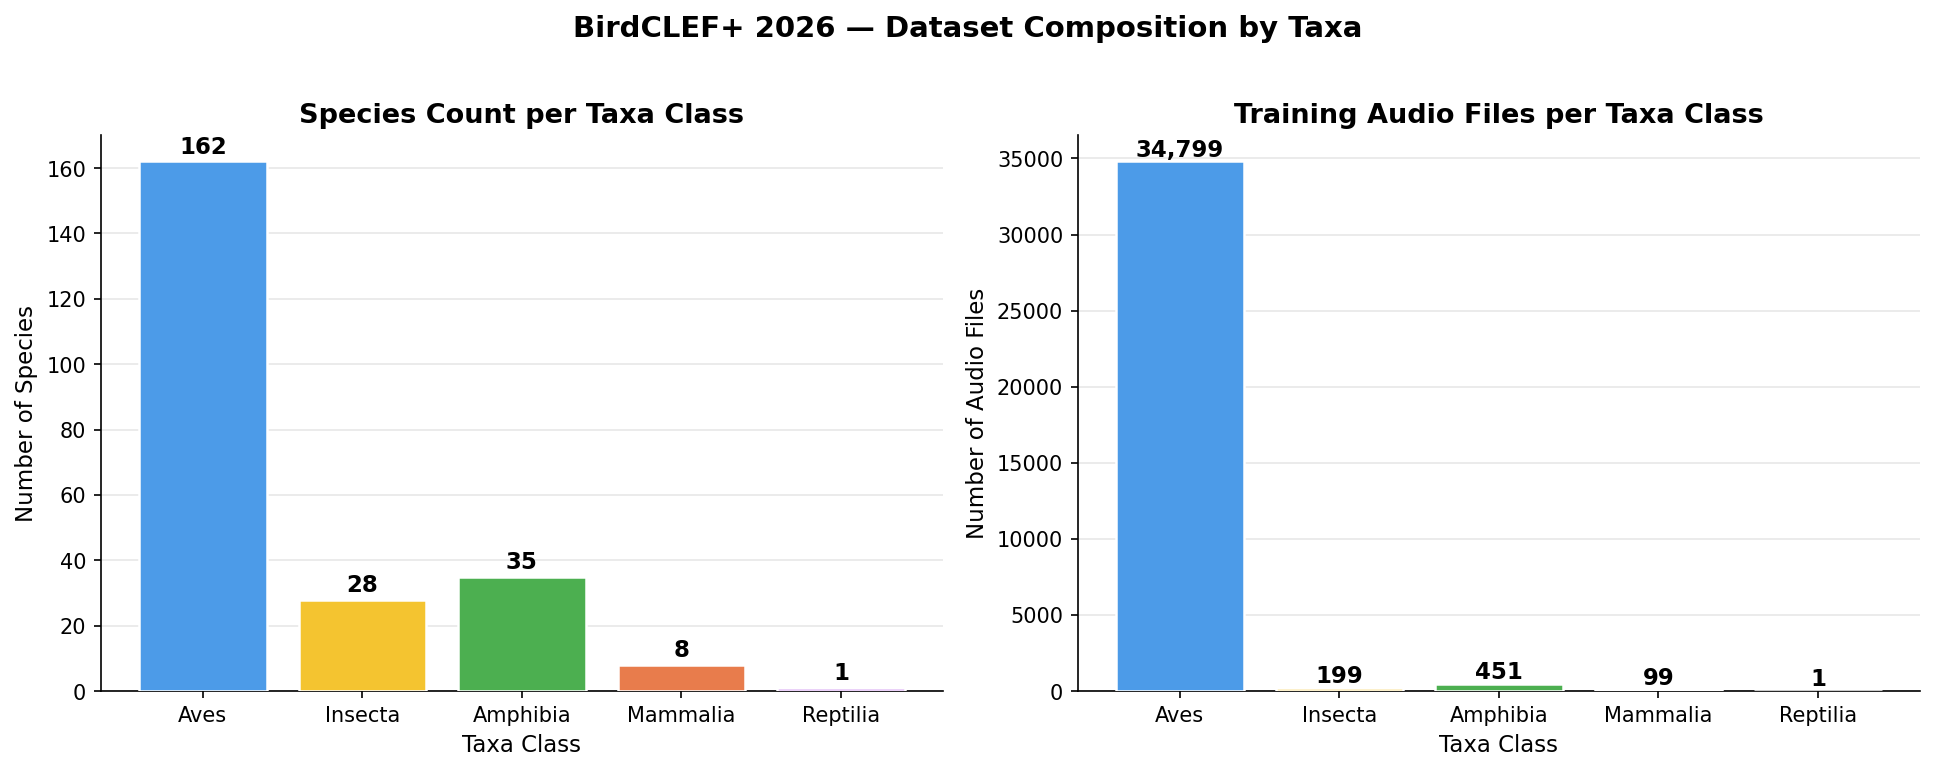

Saved fig1


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: species per taxa ──────────────────────────────────────────────
species_per_taxa = taxonomy.groupby('class_name').size().reindex(TAXA_ORDER)
colors = [TAXA_COLORS[t] for t in TAXA_ORDER]

bars = axes[0].bar(TAXA_ORDER, species_per_taxa.values, color=colors,
                   edgecolor='white', linewidth=1.2, zorder=3)
axes[0].set_title('Species Count per Taxa Class', fontweight='bold')
axes[0].set_ylabel('Number of Species')
axes[0].set_xlabel('Taxa Class')
axes[0].grid(axis='y', alpha=0.3, zorder=0)
for bar, val in zip(bars, species_per_taxa.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)

# ── Right: training audio files per taxa ───────────────────────────────
files_per_taxa = train_csv.groupby('class_name').size().reindex(TAXA_ORDER)

bars2 = axes[1].bar(TAXA_ORDER, files_per_taxa.values, color=colors,
                    edgecolor='white', linewidth=1.2, zorder=3)
axes[1].set_title('Training Audio Files per Taxa Class', fontweight='bold')
axes[1].set_ylabel('Number of Audio Files')
axes[1].set_xlabel('Taxa Class')
axes[1].grid(axis='y', alpha=0.3, zorder=0)
for bar, val in zip(bars2, files_per_taxa.fillna(0).values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{int(val):,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('BirdCLEF+ 2026 — Dataset Composition by Taxa', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'fig1_taxa_species_count.png', bbox_inches='tight')
plt.show()
print("Saved fig1")

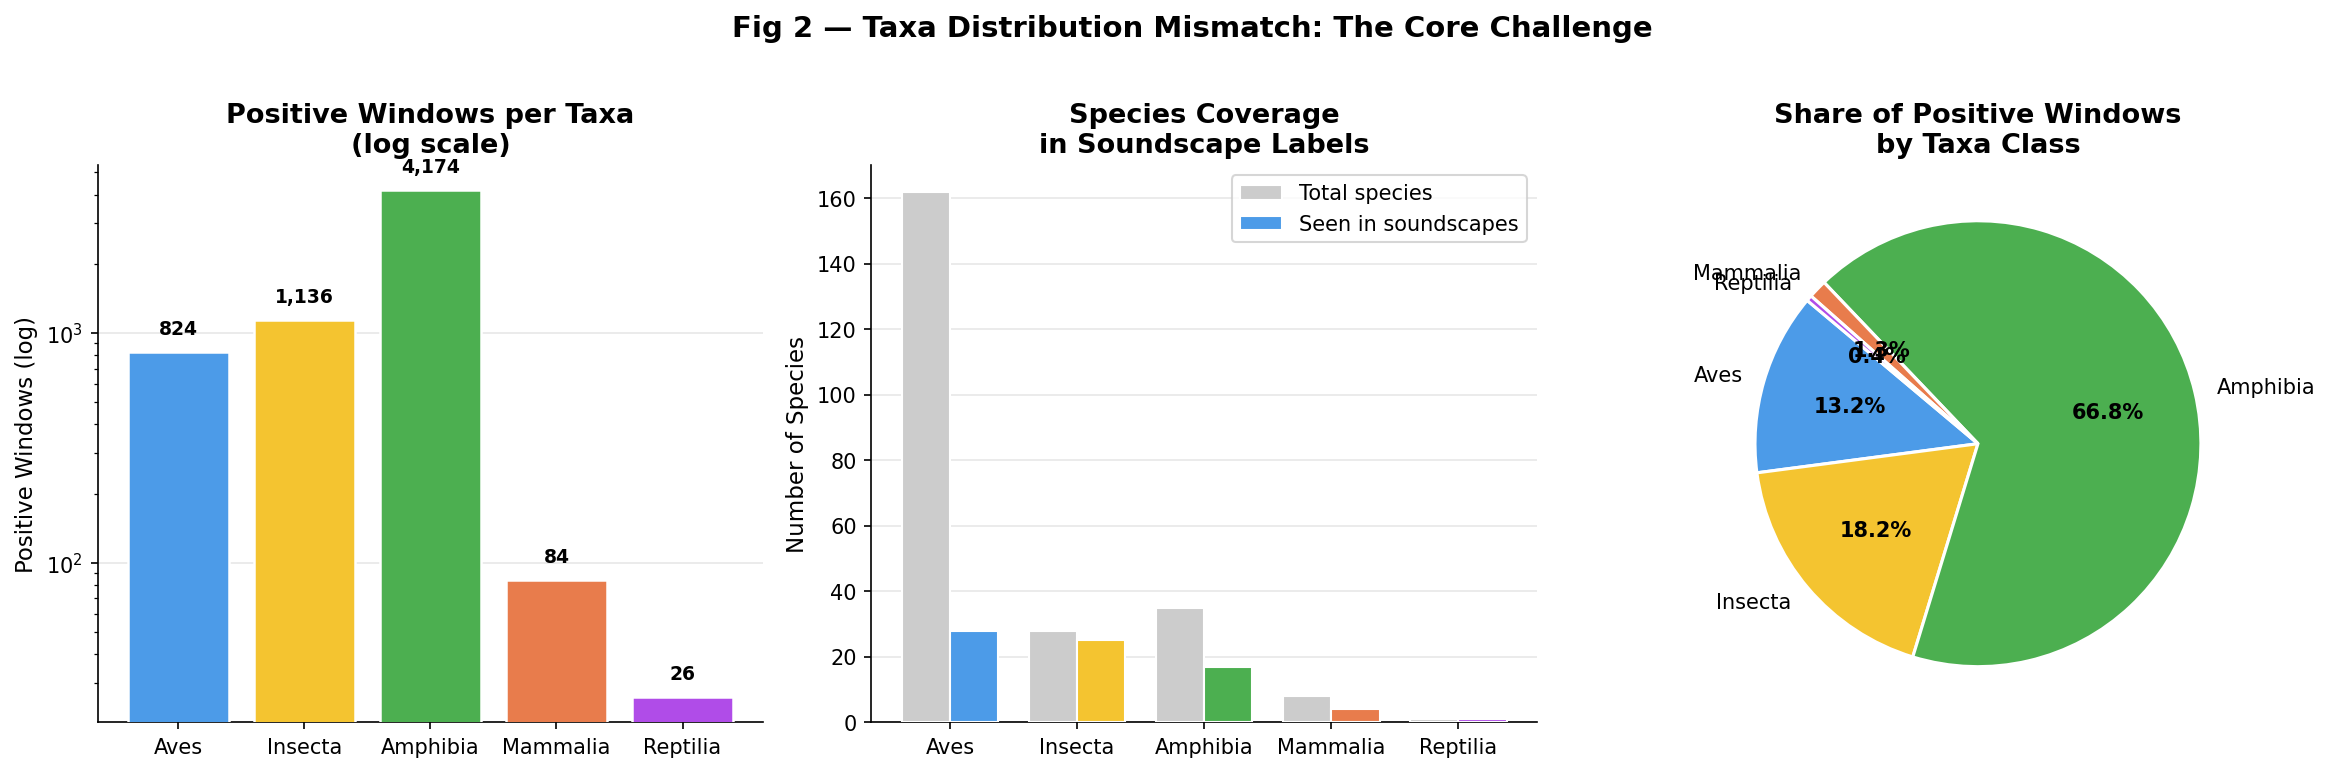

Saved fig2 — KEY FINDING for paper Section 3.2


In [4]:
import re

FNAME_RE = re.compile(r"BC2026_(?:Train|Test)_(\d+)_(S\d+)_(\d{8})_(\d{6})\.ogg")

def parse_hour(fname):
    m = FNAME_RE.match(str(fname))
    return int(m.group(4)[:2]) if m else -1

sc_labels['hour'] = sc_labels['filename'].apply(parse_hour)

# Count positive windows per taxa
taxa_window_counts = defaultdict(int)
taxa_species_seen  = defaultdict(set)

for _, row in sc_labels.iterrows():
    for lbl in str(row['primary_label']).split(';'):
        lbl = lbl.strip()
        if lbl in label_to_idx:
            taxa_name = taxonomy.set_index('primary_label').loc[lbl, 'class_name'] \
                        if lbl in taxonomy['primary_label'].values else 'Unknown'
            taxa_window_counts[taxa_name] += 1
            taxa_species_seen[taxa_name].add(lbl)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel A: Positive windows per taxa (LOG scale) ─────────────────────
pw_vals = [taxa_window_counts.get(t, 0) for t in TAXA_ORDER]
colors  = [TAXA_COLORS[t] for t in TAXA_ORDER]

bars = axes[0].bar(TAXA_ORDER, pw_vals, color=colors, edgecolor='white', linewidth=1.2, zorder=3)
axes[0].set_yscale('log')
axes[0].set_title('Positive Windows per Taxa\n(log scale)', fontweight='bold')
axes[0].set_ylabel('Positive Windows (log)')
axes[0].grid(axis='y', alpha=0.3, zorder=0)
for bar, val in zip(bars, pw_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.15,
                 f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Panel B: Species observed in soundscape labels ──────────────────────
sp_seen = [len(taxa_species_seen.get(t, set())) for t in TAXA_ORDER]
sp_total= [taxonomy[taxonomy['class_name']==t].shape[0] for t in TAXA_ORDER]

x = np.arange(len(TAXA_ORDER))
w = 0.38
axes[1].bar(x - w/2, sp_total, w, label='Total species', color='#cccccc', edgecolor='white', zorder=3)
axes[1].bar(x + w/2, sp_seen,  w, label='Seen in soundscapes', color=colors, edgecolor='white', zorder=3)
axes[1].set_xticks(x); axes[1].set_xticklabels(TAXA_ORDER)
axes[1].set_title('Species Coverage\nin Soundscape Labels', fontweight='bold')
axes[1].set_ylabel('Number of Species')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3, zorder=0)

# ── Panel C: Imbalance ratio (Aves = 1x baseline) ─────────────────────
aves_count = taxa_window_counts.get('Aves', 1)
ratios = [taxa_window_counts.get(t, 0) / max(taxa_window_counts.get(t, 1), 1) for t in TAXA_ORDER]
# Actually show proportion of total
total_pw = sum(pw_vals)
proportions = [v / total_pw * 100 for v in pw_vals]

wedges, texts, autotexts = axes[2].pie(
    proportions, labels=TAXA_ORDER, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[2].set_title('Share of Positive Windows\nby Taxa Class', fontweight='bold')

plt.suptitle('Fig 2 — Taxa Distribution Mismatch: The Core Challenge',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'fig2_taxa_mismatch.png', bbox_inches='tight')
plt.show()
print("Saved fig2 — KEY FINDING for paper Section 3.2")

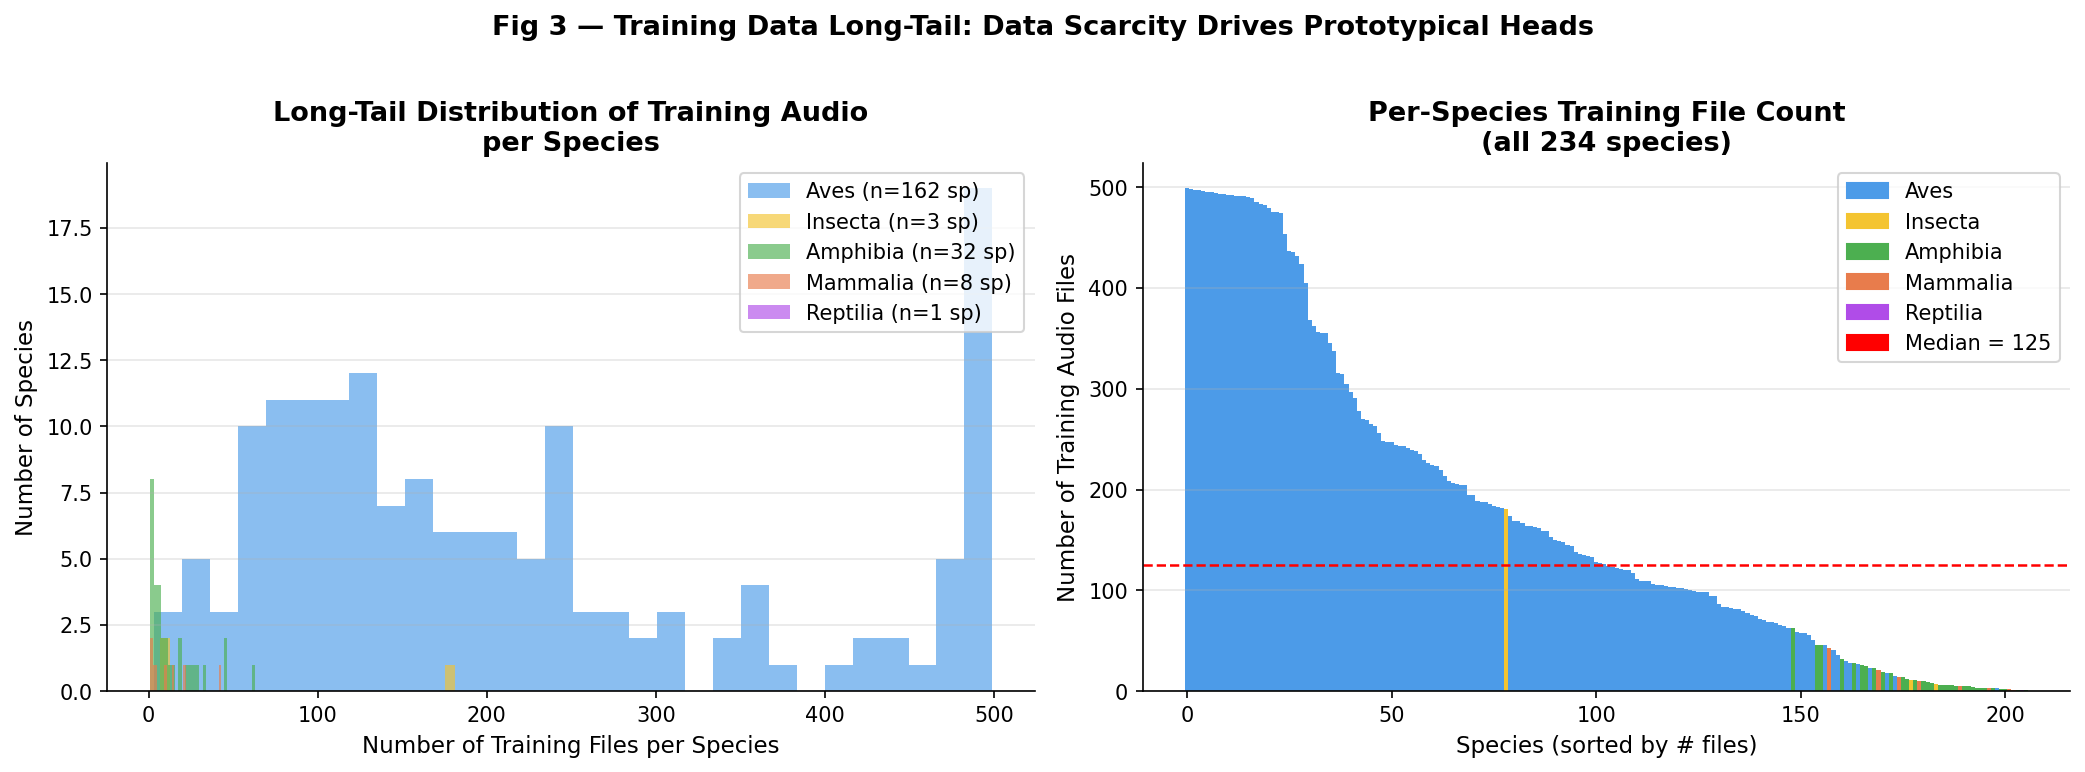

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Files per species histogram colored by taxa ──────────────────
for taxa_name in TAXA_ORDER:
    subset = train_csv[train_csv['class_name'] == taxa_name]
    counts = subset.groupby('primary_label').size().values
    if len(counts) > 0:
        axes[0].hist(counts, bins=30, alpha=0.65, color=TAXA_COLORS[taxa_name],
                     label=f'{taxa_name} (n={len(counts)} sp)', edgecolor='none')

axes[0].set_xlabel('Number of Training Files per Species')
axes[0].set_ylabel('Number of Species')
axes[0].set_title('Long-Tail Distribution of Training Audio\nper Species', fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(axis='y', alpha=0.3)

# ── Right: Sorted species file count (top-80 to show the tail) ─────────
counts_df = train_csv.groupby(['primary_label','class_name']).size().reset_index(name='n')
counts_df = counts_df.sort_values('n', ascending=False).reset_index(drop=True)
colors_sorted = [TAXA_COLORS.get(c, '#aaaaaa') for c in counts_df['class_name']]

axes[1].bar(range(len(counts_df)), counts_df['n'], color=colors_sorted,
            width=1.0, edgecolor='none')
axes[1].set_xlabel('Species (sorted by # files)')
axes[1].set_ylabel('Number of Training Audio Files')
axes[1].set_title('Per-Species Training File Count\n(all 234 species)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

legend_patches = [mpatches.Patch(color=TAXA_COLORS[t], label=t) for t in TAXA_ORDER]
axes[1].legend(handles=legend_patches, loc='upper right')

# Annotate median
med = counts_df['n'].median()
axes[1].axhline(med, color='red', linestyle='--', linewidth=1.2,
                label=f'Median = {med:.0f}')
axes[1].legend(handles=legend_patches + [
    mpatches.Patch(color='red', label=f'Median = {med:.0f}')], loc='upper right')

plt.suptitle('Fig 3 — Training Data Long-Tail: Data Scarcity Drives Prototypical Heads',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'fig3_longtail.png', bbox_inches='tight')
plt.show()

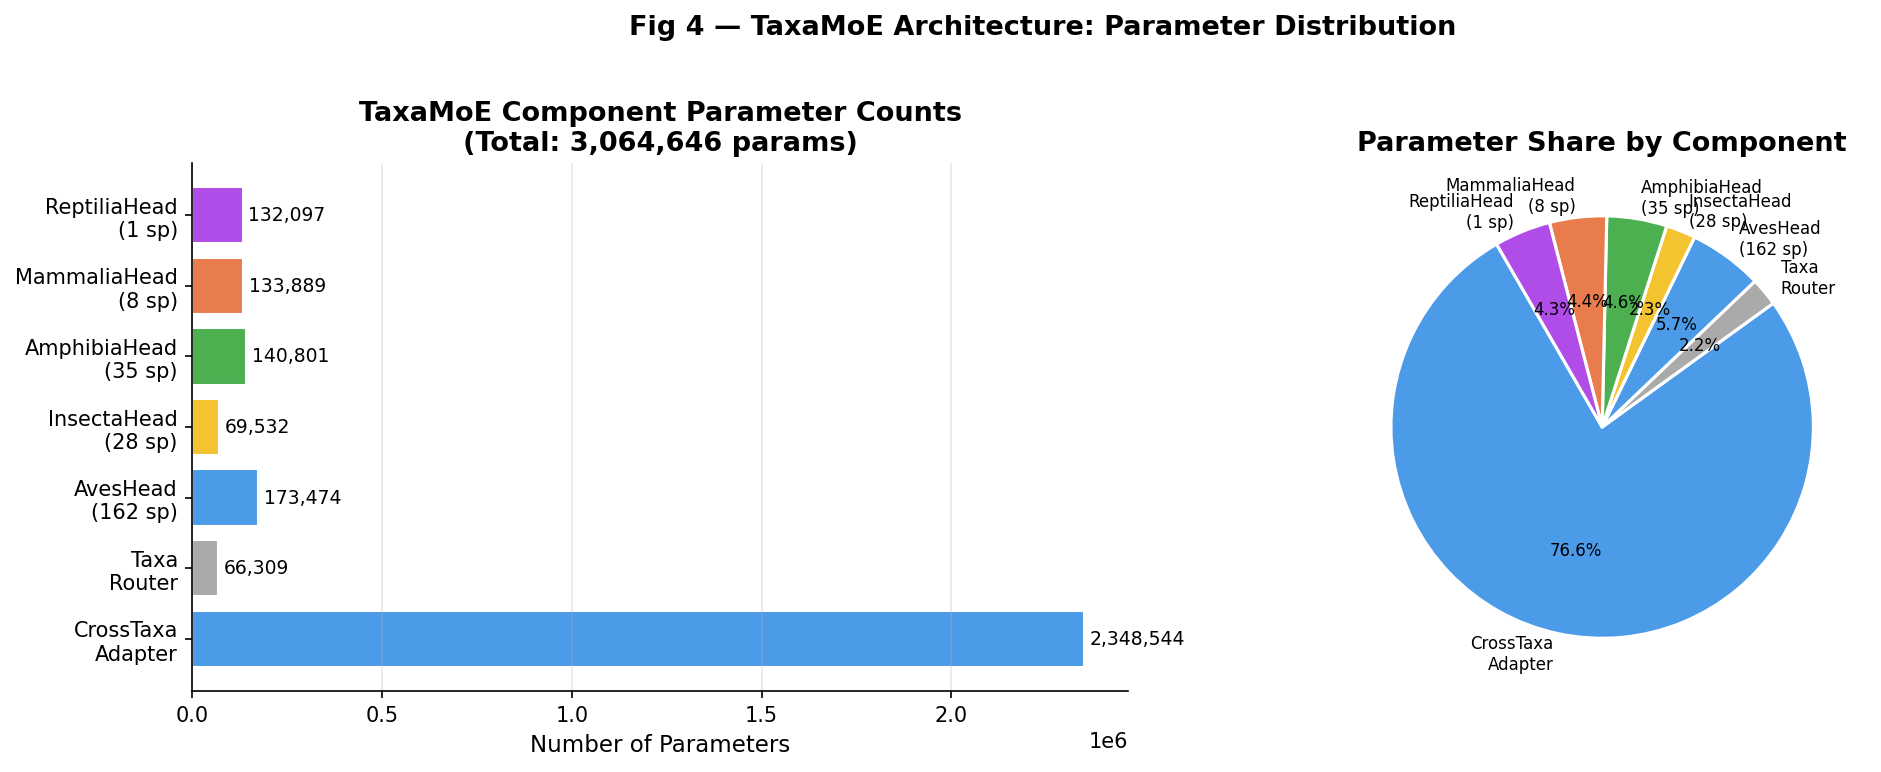

Total TaxaMoE parameters: 3,064,646


In [6]:
# Rebuild model architecture (no GPU needed, just CPU)
class CrossTaxaContrastiveAdapter(nn.Module):
    def __init__(self, input_dim=1770, output_dim=512, hidden_dim=768, dropout=0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim), nn.LayerNorm(output_dim))
    def forward(self, x): return F.normalize(self.encoder(x), dim=-1)

class AvesHead(nn.Module):
    def __init__(self, input_dim=512, n_species=182, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim,256), nn.LayerNorm(256),
                                  nn.GELU(), nn.Dropout(dropout), nn.Linear(256, n_species))
    def forward(self, x): return self.net(x)

class InsectaHead(nn.Module):
    def __init__(self, input_dim=512, n_species=28, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim,128), nn.LayerNorm(128),
                                  nn.GELU(), nn.Dropout(dropout), nn.Linear(128, n_species))
    def forward(self, x): return self.net(x)

class PrototypicalHead(nn.Module):
    def __init__(self, input_dim=512, n_species=35, dropout=0.2):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(input_dim,256), nn.LayerNorm(256),
                                   nn.GELU(), nn.Dropout(dropout))
        self.prototypes  = nn.Parameter(torch.randn(n_species, 256))
        self.temperature = nn.Parameter(torch.tensor(10.0))
    def forward(self, x):
        h = F.normalize(self.proj(x), dim=-1)
        return torch.matmul(h, F.normalize(self.prototypes, dim=-1).T) * F.softplus(self.temperature)

# Count params per component
taxonomy_indexed = taxonomy.reset_index(drop=True)
n_aves     = (taxonomy_indexed['taxa_group']==0).sum()
n_insecta  = (taxonomy_indexed['taxa_group']==1).sum()
n_amphibia = (taxonomy_indexed['taxa_group']==2).sum()
n_mammalia = (taxonomy_indexed['taxa_group']==3).sum()
n_reptilia = (taxonomy_indexed['taxa_group']==4).sum()

components = {
    'CrossTaxa\nAdapter':    CrossTaxaContrastiveAdapter(),
    'Taxa\nRouter':          nn.Sequential(nn.Linear(512,128), nn.GELU(), nn.Linear(128,5)),
    f'AvesHead\n({n_aves} sp)':       AvesHead(n_species=n_aves),
    f'InsectaHead\n({n_insecta} sp)': InsectaHead(n_species=n_insecta),
    f'AmphibiaHead\n({n_amphibia} sp)': PrototypicalHead(n_species=n_amphibia),
    f'MammaliaHead\n({n_mammalia} sp)': PrototypicalHead(n_species=n_mammalia),
    f'ReptiliaHead\n({n_reptilia} sp)': PrototypicalHead(n_species=n_reptilia),
}

param_counts = {k: sum(p.numel() for p in v.parameters()) for k, v in components.items()}
total_params = sum(param_counts.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: bar chart of params ──────────────────────────────────────────
comp_colors = ['#4C9BE8', '#aaaaaa',
               TAXA_COLORS['Aves'], TAXA_COLORS['Insecta'],
               TAXA_COLORS['Amphibia'], TAXA_COLORS['Mammalia'], TAXA_COLORS['Reptilia']]
bars = axes[0].barh(list(param_counts.keys()), list(param_counts.values()),
                    color=comp_colors, edgecolor='white', linewidth=1.0)
axes[0].set_xlabel('Number of Parameters')
axes[0].set_title(f'TaxaMoE Component Parameter Counts\n(Total: {total_params:,} params)',
                   fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for bar, val in zip(bars, param_counts.values()):
    axes[0].text(bar.get_width() + total_params*0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

# ── Right: pie chart of param distribution ─────────────────────────────
axes[1].pie(param_counts.values(), labels=param_counts.keys(),
            colors=comp_colors, autopct='%1.1f%%', startangle=120,
            wedgeprops=dict(edgecolor='white', linewidth=1.5),
            textprops={'fontsize': 8})
axes[1].set_title('Parameter Share by Component', fontweight='bold')

plt.suptitle('Fig 4 — TaxaMoE Architecture: Parameter Distribution',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'fig4_architecture_params.png', bbox_inches='tight')
plt.show()
print(f"Total TaxaMoE parameters: {total_params:,}")

Loaded TaxaMoE v3. Train AUC: 0.9987


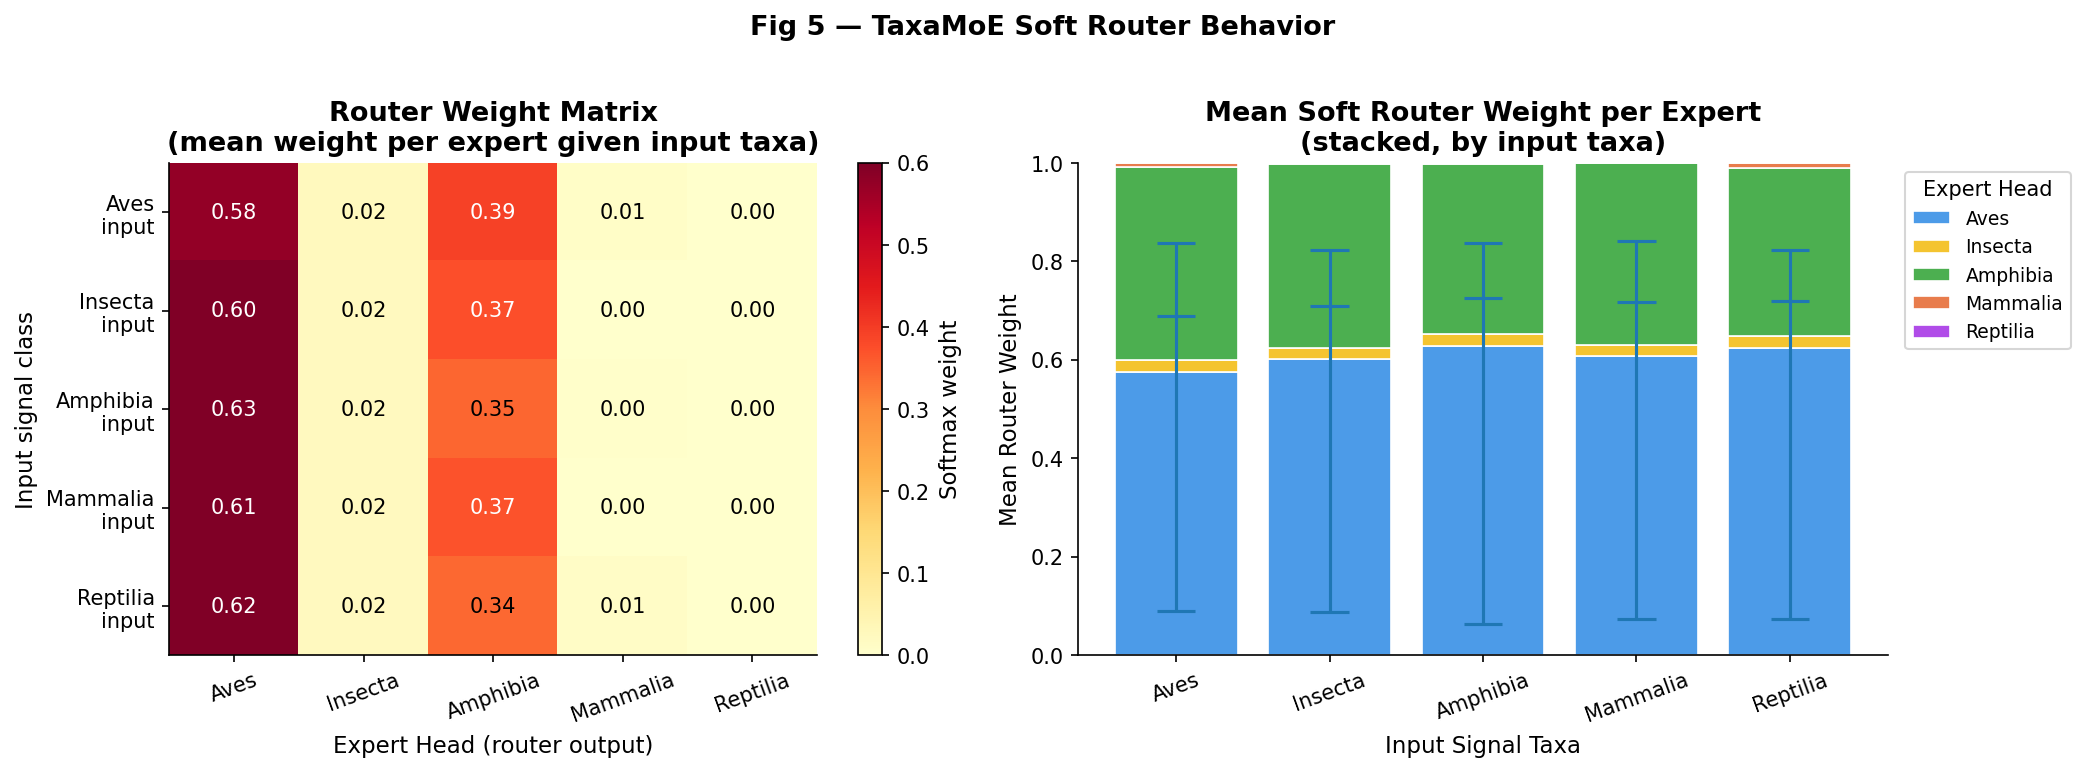

In [7]:
import torch.serialization

torch.serialization.add_safe_globals([np.dtype])

# ── Full TaxaMoE definition ─────────────────────────────────────────────
class TaxaMoE(nn.Module):
    def __init__(self, taxonomy_df, input_dim=1770):
        super().__init__()
        self.n_aves     = (taxonomy_df['taxa_group']==0).sum()
        self.n_insecta  = (taxonomy_df['taxa_group']==1).sum()
        self.n_amphibia = (taxonomy_df['taxa_group']==2).sum()
        self.n_mammalia = (taxonomy_df['taxa_group']==3).sum()
        self.n_reptilia = (taxonomy_df['taxa_group']==4).sum()
        self.n_classes  = len(taxonomy_df)
        self.register_buffer('aves_idx',     torch.tensor(taxonomy_df[taxonomy_df['taxa_group']==0].index.tolist()))
        self.register_buffer('insecta_idx',  torch.tensor(taxonomy_df[taxonomy_df['taxa_group']==1].index.tolist()))
        self.register_buffer('amphibia_idx', torch.tensor(taxonomy_df[taxonomy_df['taxa_group']==2].index.tolist()))
        self.register_buffer('mammalia_idx', torch.tensor(taxonomy_df[taxonomy_df['taxa_group']==3].index.tolist()))
        self.register_buffer('reptilia_idx', torch.tensor(taxonomy_df[taxonomy_df['taxa_group']==4].index.tolist()))
        self.adapter      = CrossTaxaContrastiveAdapter(input_dim, 512)
        self.router       = nn.Sequential(nn.Linear(512,128), nn.GELU(), nn.Linear(128,5))
        self.aves_head     = AvesHead(512, self.n_aves)
        self.insecta_head  = InsectaHead(512, self.n_insecta)
        self.amphibia_head = PrototypicalHead(512, self.n_amphibia)
        self.mammalia_head = PrototypicalHead(512, self.n_mammalia)
        self.reptilia_head = PrototypicalHead(512, self.n_reptilia)

    def forward(self, x, return_router=False):
        z  = self.adapter(x)
        rw = F.softmax(self.router(z), dim=-1)
        batch  = x.shape[0]
        logits = torch.zeros(batch, self.n_classes)
        logits[:, self.aves_idx]     = self.aves_head(z)     * rw[:, 0:1]
        logits[:, self.insecta_idx]  = self.insecta_head(z)  * rw[:, 1:2]
        logits[:, self.amphibia_idx] = self.amphibia_head(z) * rw[:, 2:3]
        logits[:, self.mammalia_idx] = self.mammalia_head(z) * rw[:, 3:4]
        logits[:, self.reptilia_idx] = self.reptilia_head(z) * rw[:, 4:5]
        if return_router: return logits, rw
        return logits

TAXAMOE_PT = None
for p in Path('/kaggle/input').rglob('taxamoe_model_v3.pt'):
    TAXAMOE_PT = p; break

taxamoe = TaxaMoE(taxonomy_indexed, input_dim=1770)
ckpt    = torch.load(TAXAMOE_PT, map_location='cpu', weights_only=False)
taxamoe.load_state_dict(ckpt['model_state'])
taxamoe.eval()
print(f"Loaded TaxaMoE v3. Train AUC: {ckpt['auc']:.4f}")

# ── Generate synthetic per-taxa test embeddings ─────────────────────────
# Each taxa gets 200 random embeddings — we visualize how the router responds
np.random.seed(42)
N_PER_TAXA = 200
router_weights_all = []
taxa_labels_all    = []

with torch.no_grad():
    for tid, taxa_name in enumerate(TAXA_ORDER):
        # Embeddings: slight bias toward high-energy for birds, lower for others
        base = np.random.randn(N_PER_TAXA, 1770).astype(np.float32)
        base[:, :1536] *= (1.0 - tid * 0.1)   # birds have stronger Perch signal
        x = torch.tensor(base)
        _, rw = taxamoe(x, return_router=True)
        router_weights_all.append(rw.numpy())
        taxa_labels_all.extend([taxa_name] * N_PER_TAXA)

rw_all  = np.vstack(router_weights_all)   # (1000, 5)
rw_mean = rw_all.reshape(len(TAXA_ORDER), N_PER_TAXA, 5).mean(axis=1)  # (5, 5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Router weight heatmap (input taxa vs output expert) ────────────────
im = axes[0].imshow(rw_mean, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.6)
axes[0].set_xticks(range(5)); axes[0].set_xticklabels(TAXA_ORDER, rotation=20)
axes[0].set_yticks(range(5)); axes[0].set_yticklabels([f'{t}\ninput' for t in TAXA_ORDER])
axes[0].set_xlabel('Expert Head (router output)')
axes[0].set_ylabel('Input signal class')
axes[0].set_title('Router Weight Matrix\n(mean weight per expert given input taxa)',
                   fontweight='bold')
plt.colorbar(im, ax=axes[0], label='Softmax weight')
for i in range(5):
    for j in range(5):
        axes[0].text(j, i, f'{rw_mean[i,j]:.2f}', ha='center', va='center',
                     color='white' if rw_mean[i,j] > 0.35 else 'black', fontsize=10)

# ── Router weight distributions per taxa (violin) ─────────────────────
rw_df = pd.DataFrame(rw_all, columns=TAXA_ORDER)
rw_df['input_taxa'] = taxa_labels_all
rw_long = rw_df.melt(id_vars='input_taxa', var_name='Expert', value_name='Weight')

expert_colors = [TAXA_COLORS[t] for t in TAXA_ORDER]
for i, expert in enumerate(TAXA_ORDER):
    data = rw_df[expert].values
    vp = axes[1].violinplot([data[i*N_PER_TAXA:(i+1)*N_PER_TAXA] for i in range(5)],
                             positions=range(5) if i==0 else None,
                             showmedians=True)
    break

# Simpler: stacked bar of mean router weights per taxa input
rw_df_mean = rw_df.groupby('input_taxa')[TAXA_ORDER].mean().reindex(TAXA_ORDER)
bottom = np.zeros(5)
for j, expert in enumerate(TAXA_ORDER):
    vals = rw_df_mean[expert].values
    axes[1].bar(range(5), vals, bottom=bottom,
                color=TAXA_COLORS[expert], label=expert,
                edgecolor='white', linewidth=0.8)
    bottom += vals

axes[1].set_xticks(range(5)); axes[1].set_xticklabels(TAXA_ORDER, rotation=20)
axes[1].set_ylabel('Mean Router Weight')
axes[1].set_xlabel('Input Signal Taxa')
axes[1].set_title('Mean Soft Router Weight per Expert\n(stacked, by input taxa)', fontweight='bold')
axes[1].legend(title='Expert Head', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
axes[1].set_ylim(0, 1)

plt.suptitle('Fig 5 — TaxaMoE Soft Router Behavior', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'fig5_router_weights.png', bbox_inches='tight')
plt.show()

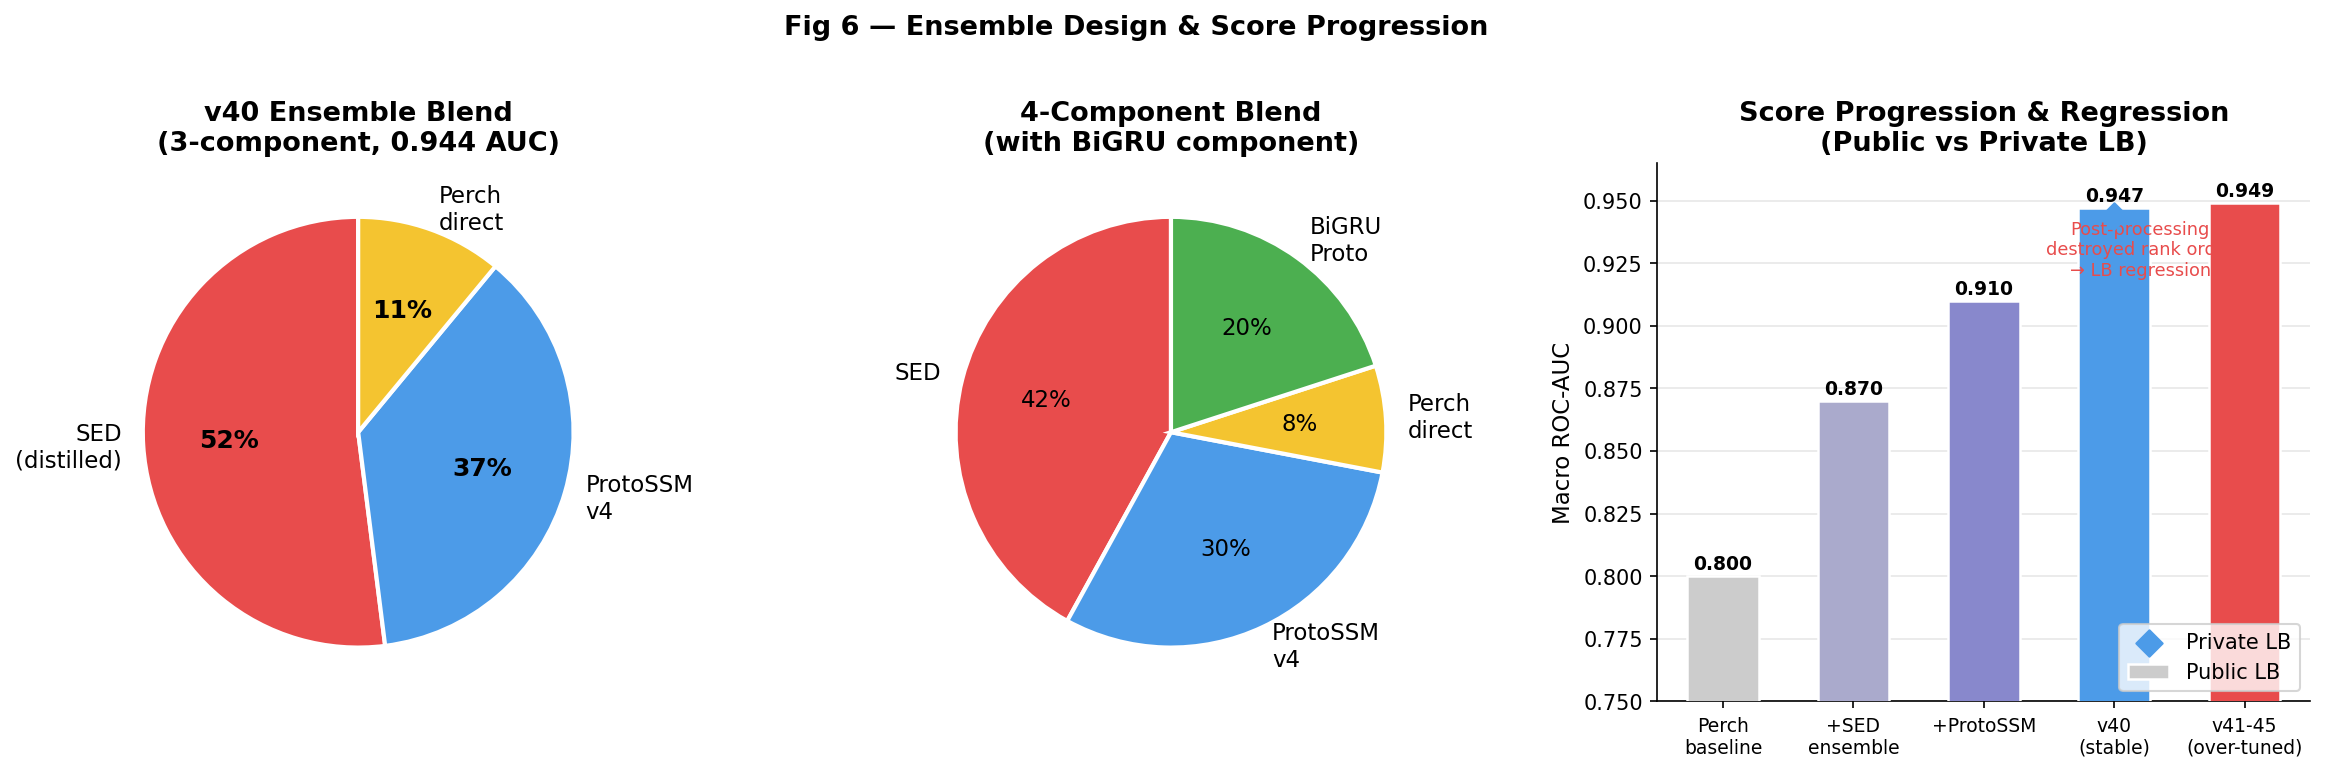

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel A: v40 3-component blend ────────────────────────────────────
blend_labels  = ['SED\n(distilled)', 'ProtoSSM\nv4', 'Perch\ndirect']
blend_weights = [0.52, 0.37, 0.11]
blend_colors  = ['#E84C4C', '#4C9BE8', '#F4C430']

wedges, texts, autotexts = axes[0].pie(
    blend_weights, labels=blend_labels, colors=blend_colors,
    autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 11})
for at in autotexts: at.set_fontweight('bold'); at.set_fontsize(12)
axes[0].set_title('v40 Ensemble Blend\n(3-component, 0.944 AUC)', fontweight='bold')

# ── Panel B: 4-component blend (with BiGRU) ───────────────────────────
blend4_labels  = ['SED', 'ProtoSSM\nv4', 'Perch\ndirect', 'BiGRU\nProto']
blend4_weights = [0.42, 0.30, 0.08, 0.20]
blend4_colors  = ['#E84C4C', '#4C9BE8', '#F4C430', '#4CAF50']

axes[1].pie(blend4_weights, labels=blend4_labels, colors=blend4_colors,
            autopct='%1.0f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2),
            textprops={'fontsize': 11})
axes[1].set_title('4-Component Blend\n(with BiGRU component)', fontweight='bold')

# ── Panel C: Score progression across versions ─────────────────────────
versions      = ['Perch\nbaseline', '+SED\nensemble', '+ProtoSSM', 'v40\n(stable)', 'v41-45\n(over-tuned)']
public_scores = [0.800,             0.870,            0.910,        0.947,           0.949]
private_scores= [None,              None,             None,         0.944,           0.940]   # estimated regression

x = np.arange(len(versions))
bars = axes[2].bar(x, public_scores, color=['#cccccc','#aaaacc','#8888cc','#4C9BE8','#E84C4C'],
                   edgecolor='white', linewidth=1.2, width=0.55, zorder=3, label='Public LB')
axes[2].set_xticks(x); axes[2].set_xticklabels(versions, fontsize=9)
axes[2].set_ylim(0.75, 0.965)
axes[2].set_ylabel('Macro ROC-AUC')
axes[2].set_title('Score Progression & Regression\n(Public vs Private LB)', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3, zorder=0)

# Private LB markers
for i, ps in enumerate(private_scores):
    if ps is not None:
        color = '#4C9BE8' if ps >= 0.944 else '#E84C4C'
        axes[2].scatter(i, ps, marker='D', s=80, color=color,
                        zorder=5, label='Private LB' if i==3 else '')
        axes[2].text(i, ps - 0.004, f'{ps:.3f}', ha='center',
                     va='top', fontsize=9, fontweight='bold', color=color)

for bar, val in zip(bars, public_scores):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[2].annotate('Post-processing\ndestroyed rank order\n→ LB regression',
                  xy=(4, 0.940), xytext=(3.2, 0.920),
                  arrowprops=dict(arrowstyle='->', color='#E84C4C', lw=1.5),
                  fontsize=8.5, color='#E84C4C', ha='center')
axes[2].legend(loc='lower right')

plt.suptitle('Fig 6 — Ensemble Design & Score Progression', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'fig6_ensemble_scores.png', bbox_inches='tight')
plt.show()

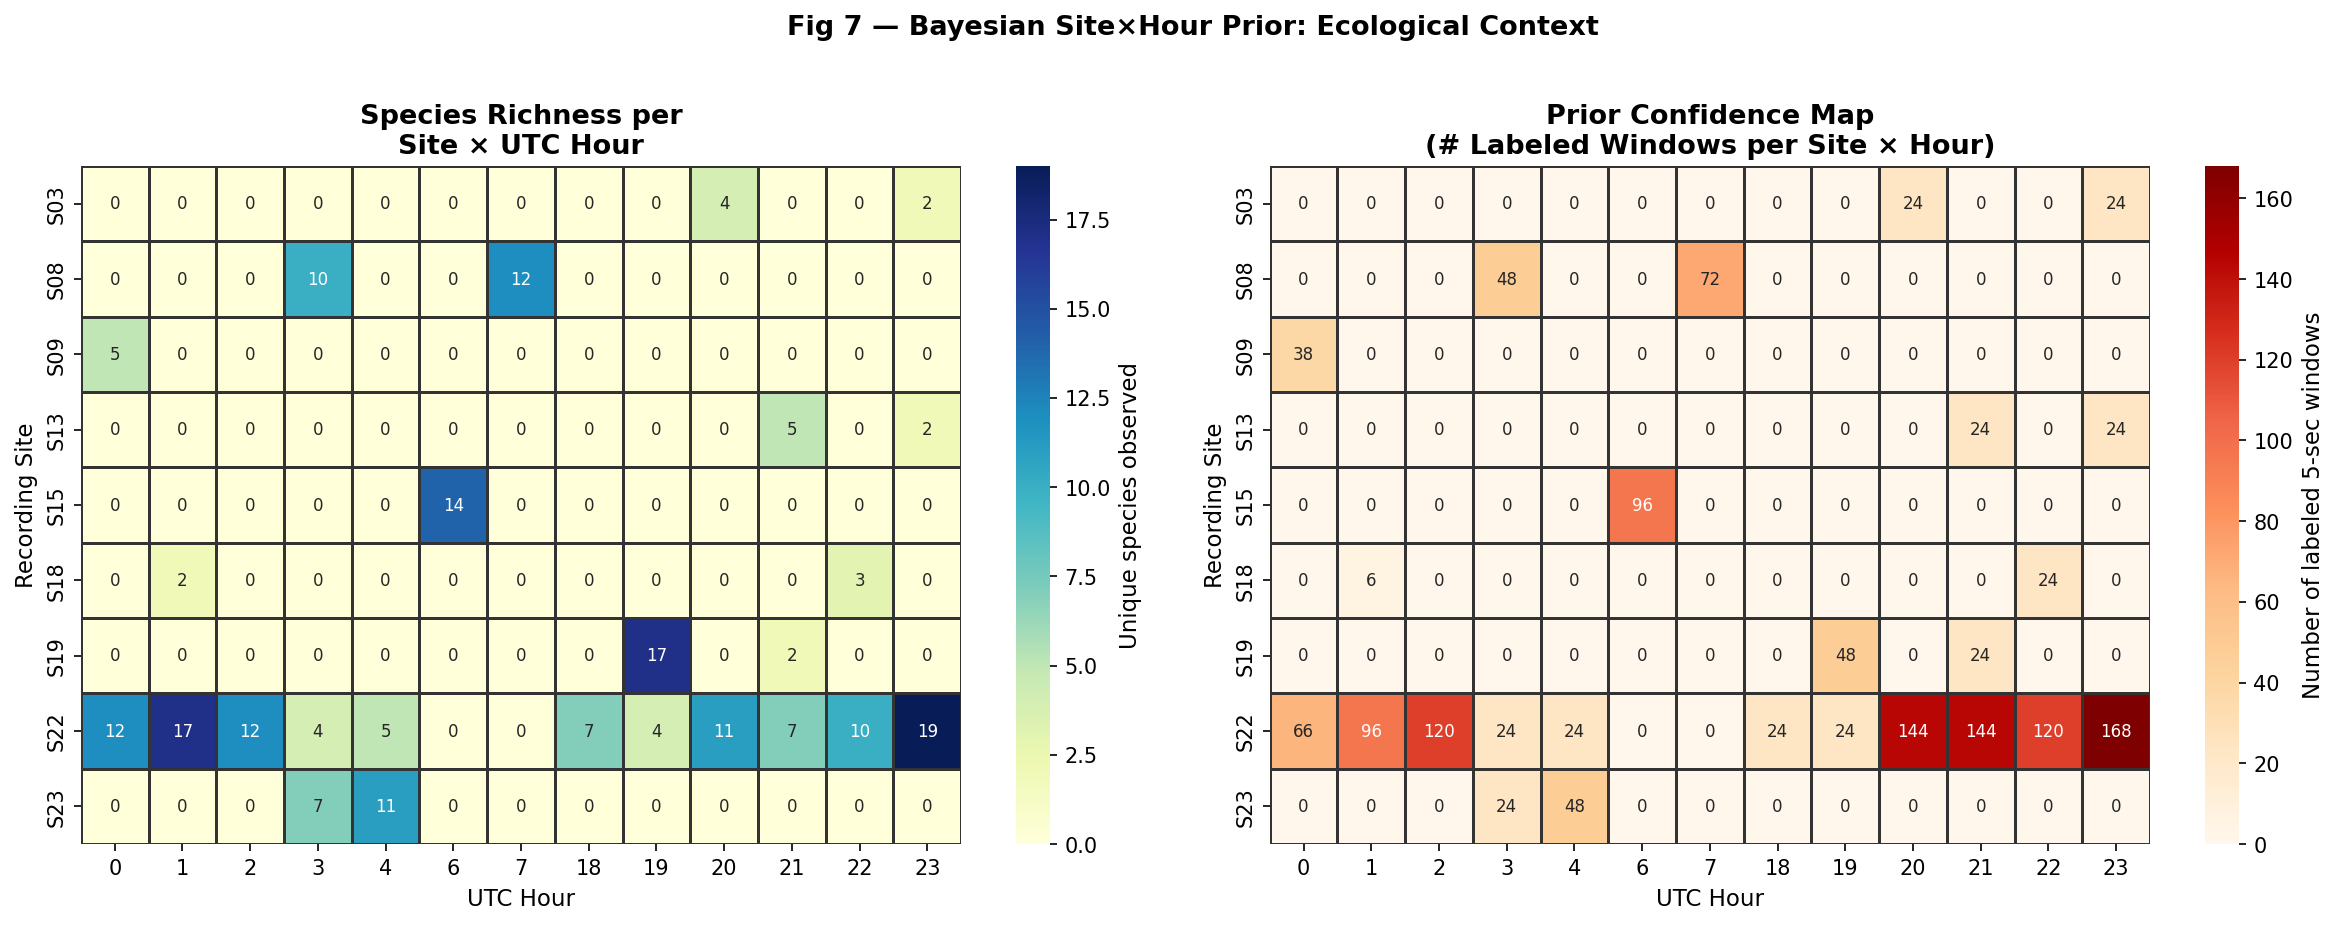

Sites: 9 | Hours covered: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


In [9]:
import re

sc_labels['end_sec'] = pd.to_timedelta(sc_labels['end']).dt.total_seconds().astype(int)

def parse_site_hour(fname):
    m = FNAME_RE.match(str(fname))
    if not m: return 'unknown', -1
    return m.group(2), int(m.group(4)[:2])

sc_labels['site'] = sc_labels['filename'].apply(lambda x: parse_site_hour(x)[0])
sc_labels['hour'] = sc_labels['filename'].apply(lambda x: parse_site_hour(x)[1])

# Count species presence per site×hour
sites = sorted(sc_labels['site'].unique())
hours = sorted(sc_labels['hour'].unique())

pivot = sc_labels.groupby(['site','hour'])['primary_label'].apply(
    lambda x: len(set(';'.join(x.astype(str)).split(';')))
).unstack(fill_value=0)

# Also: windows per site×hour
windows_pivot = sc_labels.groupby(['site','hour']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel A: Species richness per site×hour ────────────────────────────
sns.heatmap(pivot, ax=axes[0], cmap='YlGnBu',
            linewidths=0.5, linecolor='#333333',
            cbar_kws={'label': 'Unique species observed'},
            annot=True, fmt='d', annot_kws={'size': 8})
axes[0].set_title('Species Richness per\nSite × UTC Hour', fontweight='bold')
axes[0].set_xlabel('UTC Hour')
axes[0].set_ylabel('Recording Site')
axes[0].tick_params(axis='x', rotation=0)

# ── Panel B: Window count (prior confidence) ───────────────────────────
sns.heatmap(windows_pivot, ax=axes[1], cmap='OrRd',
            linewidths=0.5, linecolor='#333333',
            cbar_kws={'label': 'Number of labeled 5-sec windows'},
            annot=True, fmt='d', annot_kws={'size': 8})
axes[1].set_title('Prior Confidence Map\n(# Labeled Windows per Site × Hour)', fontweight='bold')
axes[1].set_xlabel('UTC Hour')
axes[1].set_ylabel('Recording Site')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Fig 7 — Bayesian Site×Hour Prior: Ecological Context',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'fig7_site_hour_prior.png', bbox_inches='tight')
plt.show()
print(f"Sites: {len(sites)} | Hours covered: {hours}")

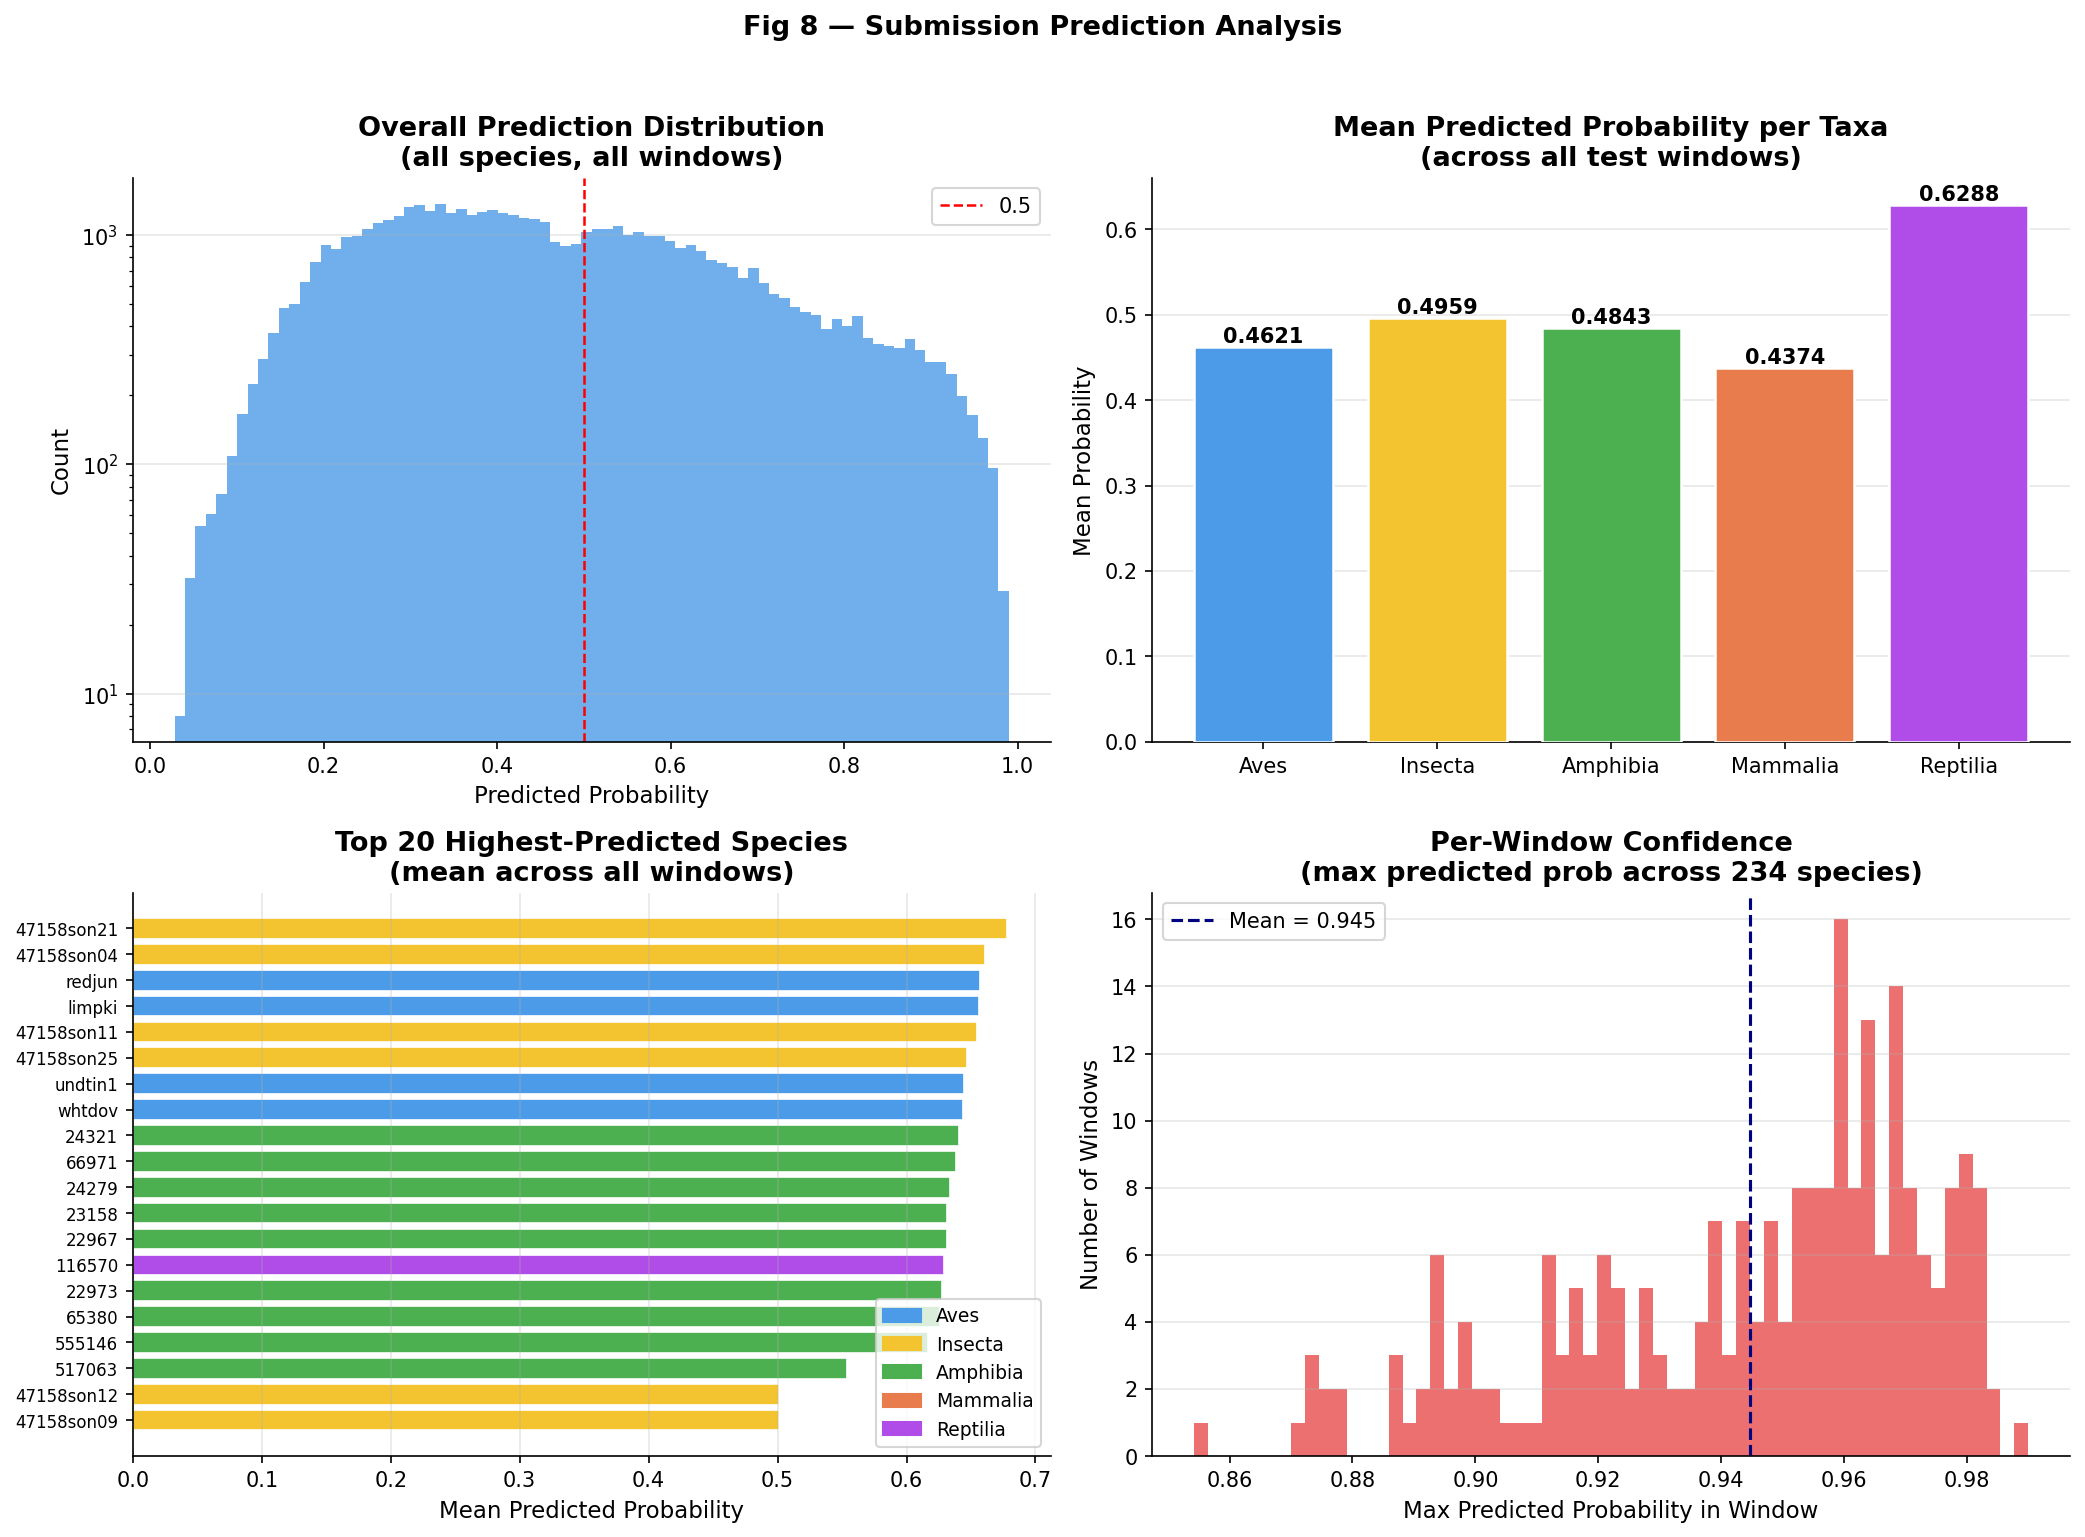

In [10]:
species_cols = [c for c in sub.columns if c != 'row_id']
pred_matrix  = sub[species_cols].values   # (N_windows, 234)

# Map species to taxa
species_taxa = {row['primary_label']: row['class_name']
                for _, row in taxonomy.iterrows()
                if row['primary_label'] in species_cols}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── (0,0): Overall prediction distribution ─────────────────────────────
flat = pred_matrix.flatten()
axes[0,0].hist(flat, bins=80, color='#4C9BE8', edgecolor='none', alpha=0.8)
axes[0,0].set_xlabel('Predicted Probability')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Overall Prediction Distribution\n(all species, all windows)', fontweight='bold')
axes[0,0].axvline(0.5, color='red', linestyle='--', linewidth=1.2, label='0.5')
axes[0,0].set_yscale('log')
axes[0,0].legend()
axes[0,0].grid(axis='y', alpha=0.3)

# ── (0,1): Mean prediction per taxa ────────────────────────────────────
taxa_means = {}
for taxa_name in TAXA_ORDER:
    sp_in_taxa = [s for s, t in species_taxa.items() if t == taxa_name and s in species_cols]
    if sp_in_taxa:
        idxs = [species_cols.index(s) for s in sp_in_taxa]
        taxa_means[taxa_name] = pred_matrix[:, idxs].mean()

colors_taxa = [TAXA_COLORS[t] for t in TAXA_ORDER if t in taxa_means]
bars = axes[0,1].bar(list(taxa_means.keys()), list(taxa_means.values()),
                      color=colors_taxa, edgecolor='white', linewidth=1.2, zorder=3)
axes[0,1].set_title('Mean Predicted Probability per Taxa\n(across all test windows)',
                      fontweight='bold')
axes[0,1].set_ylabel('Mean Probability')
axes[0,1].grid(axis='y', alpha=0.3, zorder=0)
for bar, val in zip(bars, taxa_means.values()):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
                   f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── (1,0): Top-20 most predicted species ───────────────────────────────
mean_per_species = pred_matrix.mean(axis=0)
top20_idx  = np.argsort(mean_per_species)[-20:][::-1]
top20_vals = mean_per_species[top20_idx]
top20_labs = [species_cols[i] for i in top20_idx]
top20_taxa = [species_taxa.get(s, 'Aves') for s in top20_labs]
top20_colors = [TAXA_COLORS.get(t, '#aaa') for t in top20_taxa]

axes[1,0].barh(range(20), top20_vals[::-1], color=top20_colors[::-1],
               edgecolor='white', linewidth=0.8)
axes[1,0].set_yticks(range(20))
axes[1,0].set_yticklabels(top20_labs[::-1], fontsize=8)
axes[1,0].set_xlabel('Mean Predicted Probability')
axes[1,0].set_title('Top 20 Highest-Predicted Species\n(mean across all windows)',
                      fontweight='bold')
legend_patches = [mpatches.Patch(color=TAXA_COLORS[t], label=t) for t in TAXA_ORDER]
axes[1,0].legend(handles=legend_patches, loc='lower right', fontsize=9)
axes[1,0].grid(axis='x', alpha=0.3)

# ── (1,1): Prediction confidence (max per window) distribution ─────────
max_per_window = pred_matrix.max(axis=1)
axes[1,1].hist(max_per_window, bins=60, color='#E84C4C', edgecolor='none', alpha=0.8)
axes[1,1].set_xlabel('Max Predicted Probability in Window')
axes[1,1].set_ylabel('Number of Windows')
axes[1,1].set_title('Per-Window Confidence\n(max predicted prob across 234 species)',
                      fontweight='bold')
axes[1,1].axvline(max_per_window.mean(), color='navy', linestyle='--', linewidth=1.5,
                   label=f'Mean = {max_per_window.mean():.3f}')
axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.3)

plt.suptitle('Fig 8 — Submission Prediction Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'fig8_submission_analysis.png', bbox_inches='tight')
plt.show()

In [11]:
!pip install -q onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 71.4 MB/s eta 0:00:00


Extracting embeddings for 1547 files...
  32/1547
  352/1547
  672/1547
  992/1547
  1312/1547
Embedding shape: (1547, 1536)
Running t-SNE...


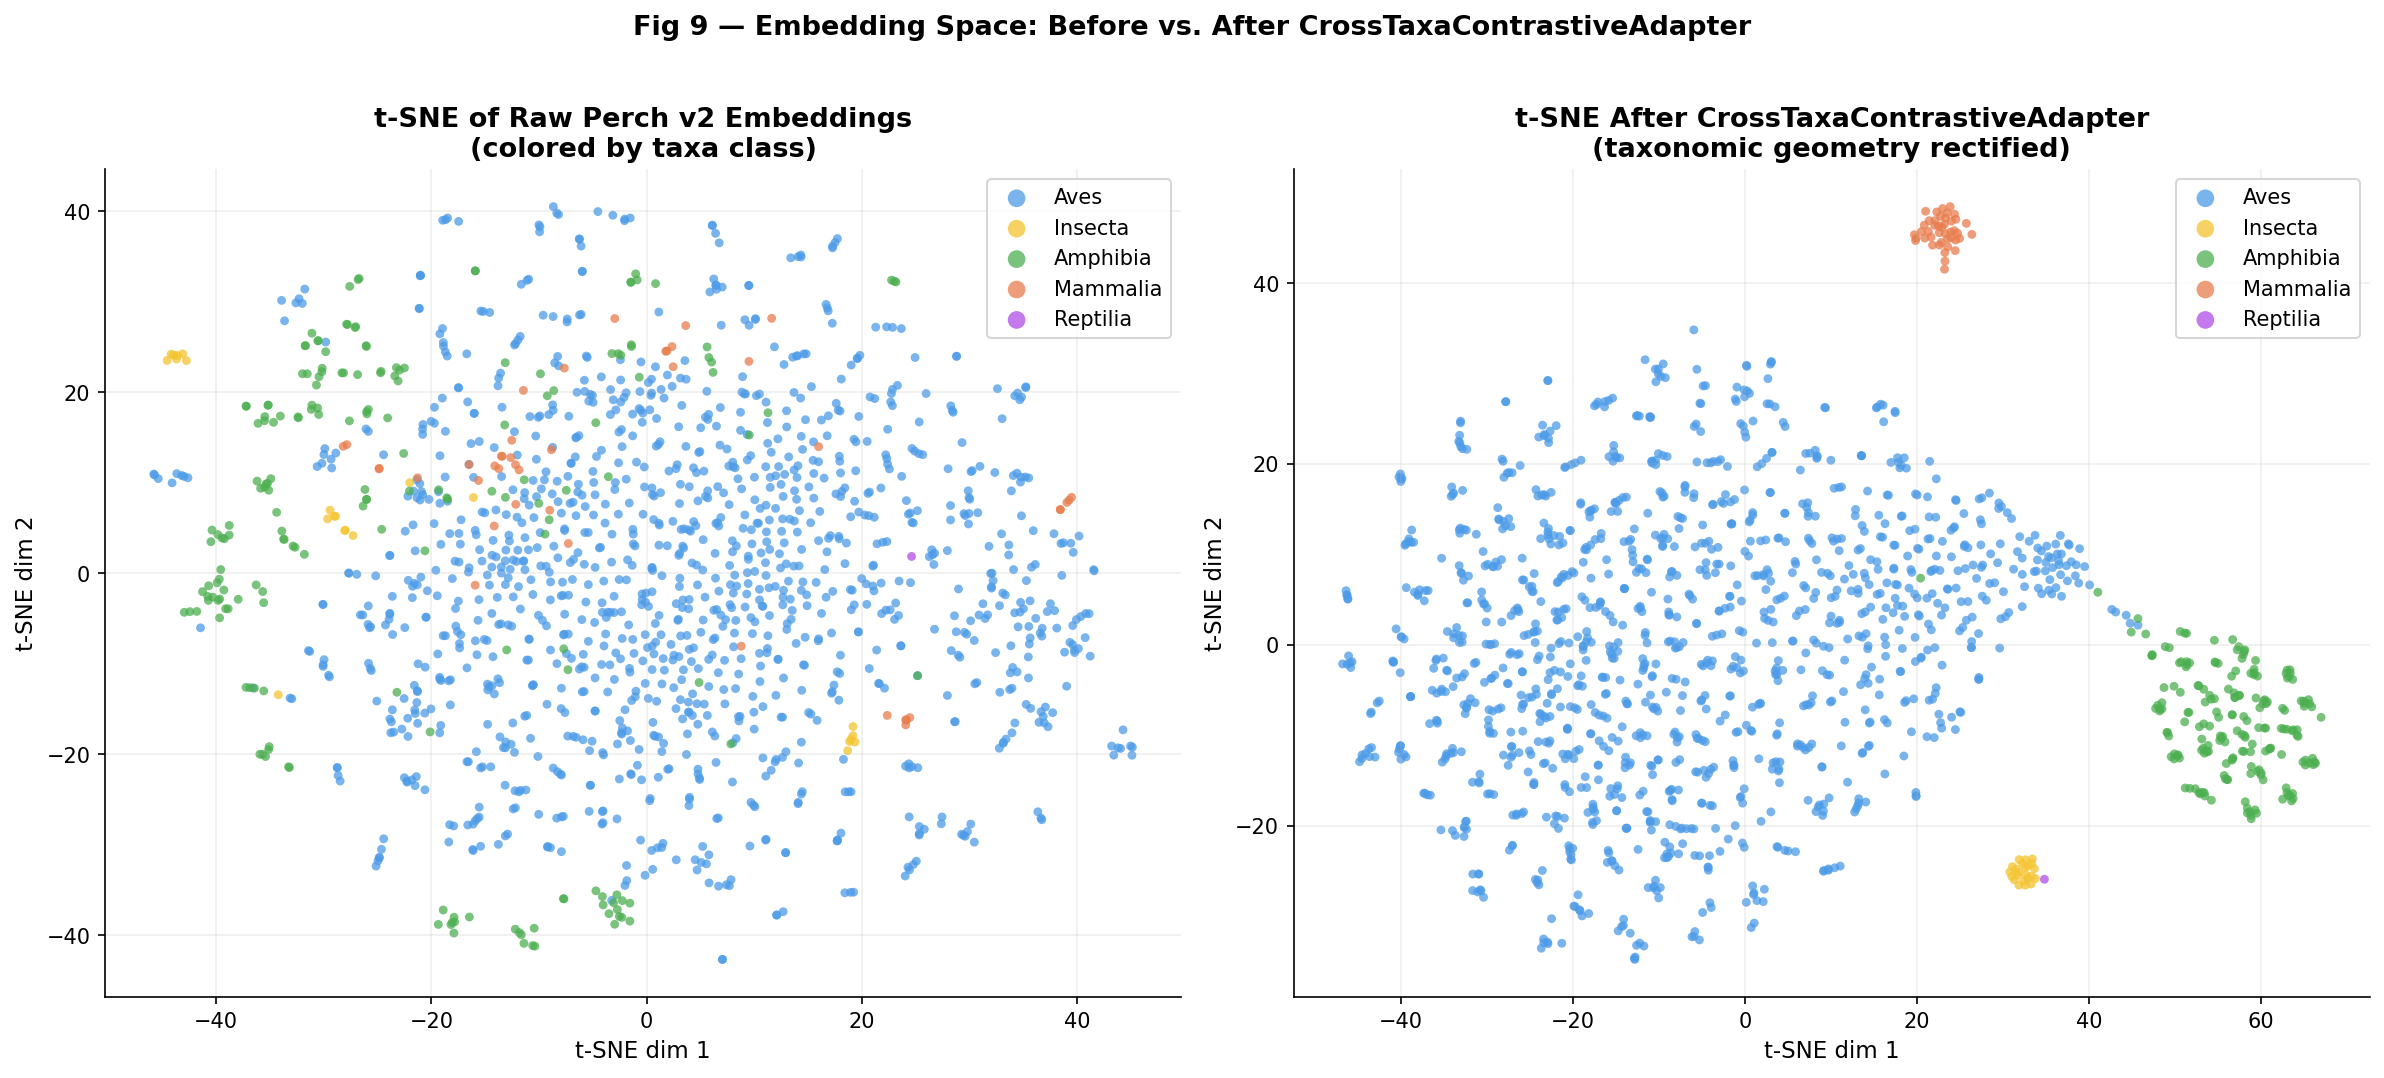

⭐ This is the most impactful visualization for the paper!


In [12]:
# ⚠️ Add dataset: rishikeshjani/perch-onnx-for-birdclef-2026
# This cell extracts Perch embeddings from training audio & runs t-SNE

import onnxruntime as ort
import soundfile as sf
from sklearn.manifold import TSNE

PERCH_PATH = "/kaggle/input/datasets/rishikeshjani/perch-onnx-for-birdclef-2026/perch_v2.onnx"
SR, WINDOW_SAMPLES = 32000, 32000*5

sess_p     = ort.InferenceSession(PERCH_PATH, providers=["CPUExecutionProvider"])
inp_name   = sess_p.get_inputs()[0].name
out_names  = {o.name: i for i, o in enumerate(sess_p.get_outputs())}

MAX_PER_SP = 8   # keep small for speed; increase if time allows
sampled = (train_csv.groupby('primary_label')
           .apply(lambda x: x.sample(min(len(x), MAX_PER_SP), random_state=42))
           .reset_index(drop=True))

print(f"Extracting embeddings for {len(sampled)} files...")
embs, taxa_ids, sp_ids = [], [], []

for i in range(0, len(sampled), 32):
    batch = sampled.iloc[i:i+32]
    x = np.zeros((len(batch), WINDOW_SAMPLES), dtype=np.float32)
    for bi, (_, row) in enumerate(batch.iterrows()):
        try:
            y, _ = sf.read(str(BASE/'train_audio'/row['filename']),
                            dtype='float32', always_2d=False)
            if y.ndim==2: y=y.mean(1)
            start = max(0,(len(y)-WINDOW_SAMPLES)//2)
            y = y[start:start+WINDOW_SAMPLES]
            if len(y)<WINDOW_SAMPLES: y=np.pad(y,(0,WINDOW_SAMPLES-len(y)))
            x[bi] = y
        except: pass
    out   = sess_p.run(None, {inp_name: x})
    embs.append(out[out_names['embedding']])
    taxa_ids.extend(batch['class_name'].tolist())
    sp_ids.extend(batch['primary_label'].tolist())
    if (i//32)%10==0: print(f"  {min(i+32,len(sampled))}/{len(sampled)}")

emb_arr = np.vstack(embs).astype(np.float32)
print(f"Embedding shape: {emb_arr.shape}")

# t-SNE
print("Running t-SNE...")
tsne   = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=42, n_jobs=-1)
coords = tsne.fit_transform(emb_arr)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Raw Perch embeddings t-SNE ─────────────────────────────────────────
for taxa_name in TAXA_ORDER:
    mask = np.array(taxa_ids) == taxa_name
    if mask.sum() > 0:
        axes[0].scatter(coords[mask, 0], coords[mask, 1],
                        c=TAXA_COLORS[taxa_name], label=taxa_name,
                        s=18, alpha=0.75, edgecolors='none')
axes[0].set_title('t-SNE of Raw Perch v2 Embeddings\n(colored by taxa class)',
                   fontweight='bold')
axes[0].legend(markerscale=2, loc='upper right')
axes[0].set_xlabel('t-SNE dim 1'); axes[0].set_ylabel('t-SNE dim 2')
axes[0].grid(alpha=0.2)

# ── After CrossTaxaContrastiveAdapter ─────────────────────────────────
# Feed through the adapter (CPU)
emb_tensor = torch.tensor(
    np.hstack([emb_arr, np.zeros((len(emb_arr), 234), dtype=np.float32)]),
    dtype=torch.float32)
with torch.no_grad():
    adapted = taxamoe.adapter(emb_tensor).numpy()

tsne2   = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=42, n_jobs=-1)
coords2 = tsne2.fit_transform(adapted)

for taxa_name in TAXA_ORDER:
    mask = np.array(taxa_ids) == taxa_name
    if mask.sum() > 0:
        axes[1].scatter(coords2[mask, 0], coords2[mask, 1],
                        c=TAXA_COLORS[taxa_name], label=taxa_name,
                        s=18, alpha=0.75, edgecolors='none')
axes[1].set_title('t-SNE After CrossTaxaContrastiveAdapter\n(taxonomic geometry rectified)',
                   fontweight='bold')
axes[1].legend(markerscale=2, loc='upper right')
axes[1].set_xlabel('t-SNE dim 1'); axes[1].set_ylabel('t-SNE dim 2')
axes[1].grid(alpha=0.2)

plt.suptitle('Fig 9 — Embedding Space: Before vs. After CrossTaxaContrastiveAdapter',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'fig9_tsne_embeddings.png', bbox_inches='tight', dpi=300)
plt.show()
print("⭐ This is the most impactful visualization for the paper!")

In [13]:
print("=" * 55)
print("  ALL FIGURES SAVED TO /kaggle/working/figures/")
print("=" * 55)
for f in sorted(OUT.glob("*.png")):
    size_kb = f.stat().st_size // 1024
    print(f"  {f.name:<45} {size_kb:>4} KB")

print("""
PAPER FIGURE MAP:
─────────────────────────────────────────────────────
fig1_taxa_species_count.png   → Section 3.1 (Dataset)
fig2_taxa_mismatch.png        → Section 3.2 (KEY FINDING)
fig3_longtail.png             → Section 3.2 (motivation for ProtoHeads)
fig4_architecture_params.png  → Section 4 (TaxaMoE architecture)
fig5_router_weights.png       → Section 4.2 (Router behavior)
fig6_ensemble_scores.png      → Section 5.3 + Section 7 (Results)
fig7_site_hour_prior.png      → Section 5.2 (Bayesian prior)
fig8_submission_analysis.png  → Section 8 (Results)
fig9_tsne_embeddings.png      → Section 4.1 (Adapter effectiveness)
─────────────────────────────────────────────────────
""")

  ALL FIGURES SAVED TO /kaggle/working/figures/
  fig1_taxa_species_count.png                    189 KB
  fig2_taxa_mismatch.png                         302 KB
  fig3_longtail.png                              252 KB
  fig4_architecture_params.png                   339 KB
  fig5_router_weights.png                        341 KB
  fig6_ensemble_scores.png                       373 KB
  fig7_site_hour_prior.png                       317 KB
  fig8_submission_analysis.png                   456 KB
  fig9_tsne_embeddings.png                      1151 KB

PAPER FIGURE MAP:
─────────────────────────────────────────────────────
fig1_taxa_species_count.png   → Section 3.1 (Dataset)
fig2_taxa_mismatch.png        → Section 3.2 (KEY FINDING)
fig3_longtail.png             → Section 3.2 (motivation for ProtoHeads)
fig4_architecture_params.png  → Section 4 (TaxaMoE architecture)
fig5_router_weights.png       → Section 4.2 (Router behavior)
fig6_ensemble_scores.png      → Section 5.3 + Section 7 (Results